In [15]:
import networkx as nx
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from graphlab.graph import build_graph
from graphlab.visualization import view_graph, plot_neighborhood
from graphlab.data import load_and_split_features
from graphlab.models import build_rf_baseline
from graphlab.evaluation import evaluate_binary_classifier

In [3]:
G = build_graph("../data/txs_edgelist.csv", "../data/txs_features.csv", "../data/txs_classes.csv")

In [4]:
components = sorted(
    nx.weakly_connected_components(G),
    key=len,
    reverse=True
)

largest = G.subgraph(components[5]).copy()

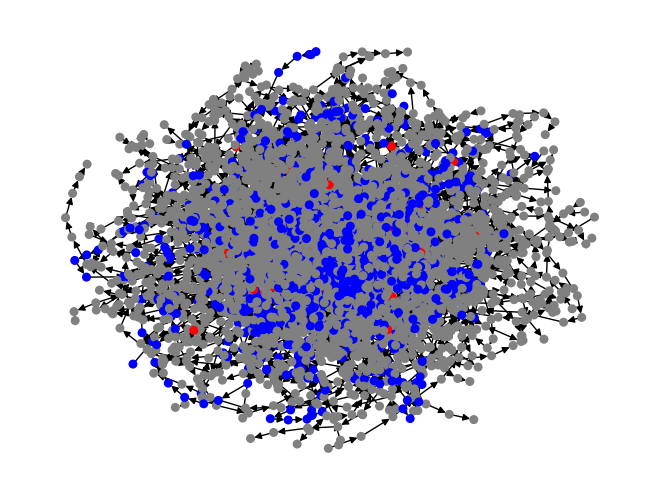

In [5]:
view_graph(largest)

In [6]:
pagerank = nx.pagerank(G)

top_nodes = sorted(
    pagerank,
    key=pagerank.get,
    reverse=True
)[:500]

G_top = G.subgraph(top_nodes).copy()

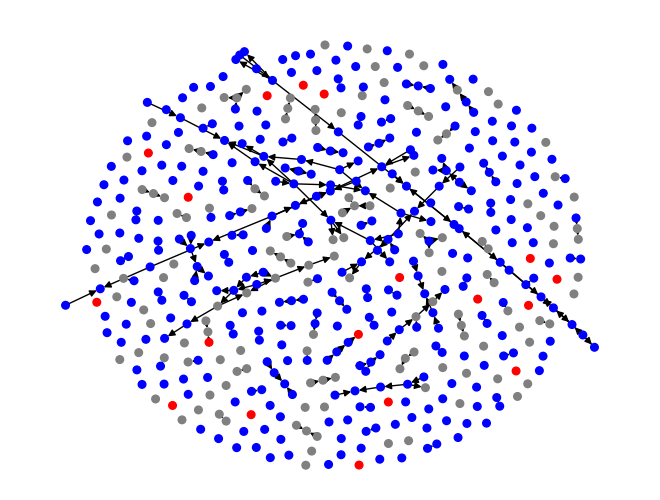

In [7]:
view_graph(G_top)

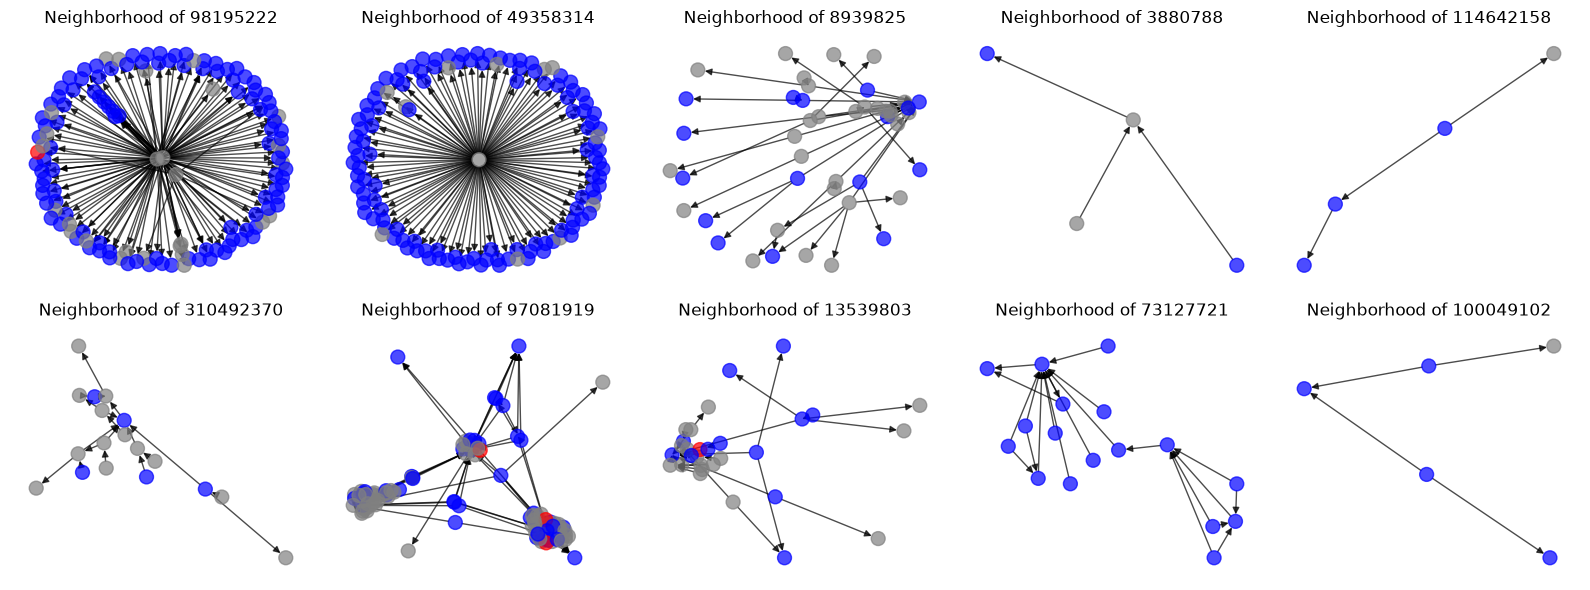

In [8]:
illicit_nodes = [n for n, data in G.nodes(data=True) if data['class'] == 2]

random_illicit_nodes = np.random.choice(illicit_nodes, 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(16, 6))

for i, n in enumerate(random_illicit_nodes):
    row = i // 5
    col = i % 5
    plot_neighborhood(G, n, radius=2, ax=axes[row, col])

plt.tight_layout()
plt.show()

In [9]:
X_train, y_train, X_val, y_val, X_test, y_test = load_and_split_features("../data/txs_features.csv", "../data/txs_classes.csv", txId=True, compute=True, G=G)

/home/yro/graphml-lab/src/graphlab/data.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(loc=2, column='class', value=df_classes['class'])
/home/yro/graphml-lab/src/graphlab/features.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['in_degree'] = df['txId'].map(in_degree)
/home/yro/graphml-lab/src/graphlab/features.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using 

In [10]:
rf_model = build_rf_baseline()

In [11]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](191,)","['txId','Time step','Local_feature_1',...,'neighbors_1hop', 'neighbors_2hop','clustering']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,191
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42


In [12]:
val_result_rf = evaluate_binary_classifier(rf_model, X_val, y_val)

In [13]:
print("Validation Random Forest Classifier")
print(val_result_rf["classification_report"])

Validation Random Forest Classifier
              precision    recall  f1-score   support

           1       0.98      0.97      0.98       690
           2       0.99      1.00      1.00      3591

    accuracy                           0.99      4281
   macro avg       0.99      0.98      0.99      4281
weighted avg       0.99      0.99      0.99      4281



In [18]:
results_table = pd.DataFrame({
    "Model": ["Random Forest"],
    "PR-AUC": [
        val_result_rf["pr_auc"]
    ],
    "ROC-AUC": [
        val_result_rf["roc_auc"]
    ]
})

results_table

,Model,PR-AUC,ROC-AUC
0,Random Forest,0.089422,0.997815


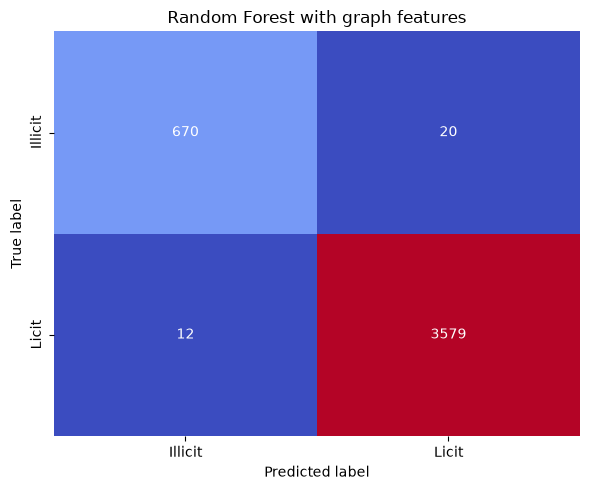

In [21]:
cm_rf = val_result_rf["confusion_matrix"]

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=["Illicit", "Licit"],
    yticklabels=["Illicit", "Licit"],
    cbar=False,
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Random Forest with graph features")

plt.tight_layout()
plt.show()